# AlexNet
相较于LeNet，AlexNet的网络结构更深，包含了更多的卷积层和全连接层。AlexNet由五个卷积层和三个全连接层组成，其中卷积层使用了ReLU激活函数，并且在某些卷积层后面添加了局部响应归一化（LRN）层来增强模型的泛化能力。此外，AlexNet还引入了Dropout来减少过拟合现象。

这里使用的是Fashion-MNIST数据集。Fashion-MNIST图像的分辨率（$28 \times 28$像素）低于ImageNet图像。

此外，我对模型进行简化，以适应较小的数据集和较低的计算资源： 
1. 减少了卷积层的输出通道数与全连接层的神经元数量。
2. 更改卷积核大小和步幅以适应输入图像的尺寸。
3. 由于输入图像较小，像素过小，难以进行多次卷积，最后效果略差于（test_acc相差0.01）原来的AlexNet，但仍然比LeNet更好。
4. 但训练时间大大缩短。

In [1]:
import torch
from torch import nn
from d2l import torch as d2l

net = nn.Sequential(
    nn.Conv2d(1, 40 , kernel_size=4, stride=2, padding=2), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),
    nn.Flatten(),
    # 这里，全连接层的输出数量是LeNet中的好几倍。使用dropout层来减轻过拟合
    nn.Linear(1960, 4096), nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(4096, 1024), nn.ReLU(),
    nn.Dropout(p=0.5),
    # 最后是输出层。由于这里使用Fashion-MNIST，所以用类别数为10，而非论文中的1000
    nn.Linear(1024, 10))

In [2]:
X = torch.randn(1, 1, 28, 28)
for layer in net:
    X=layer(X)
    print(layer.__class__.__name__,'output shape:\t',X.shape)

Conv2d output shape:	 torch.Size([1, 40, 15, 15])
ReLU output shape:	 torch.Size([1, 40, 15, 15])
MaxPool2d output shape:	 torch.Size([1, 40, 7, 7])
Flatten output shape:	 torch.Size([1, 1960])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1, 1024])
ReLU output shape:	 torch.Size([1, 1024])
Dropout output shape:	 torch.Size([1, 1024])
Linear output shape:	 torch.Size([1, 10])


In [3]:
batch_size = 64
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)

loss 0.185, train acc 0.930, test acc 0.912
20075.2 examples/sec on cuda:0


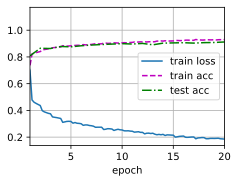

In [4]:
lr, num_epochs = 0.07, 20
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())